# 数据预处理

# 主题：在模拟过程数据上实现多元线性回归（MLR）

In [1]:
# 读取数据
import numpy as np
VSdata = np.loadtxt('VSdata.csv', delimiter=',')
VSdata_val = np.loadtxt('VSdata_val.csv', delimiter=',')

In [2]:
# 分离 X 和 y
y_train = VSdata[:,0]
X_train = VSdata[:,1:]

y_val = VSdata_val[:,0]
X_val = VSdata_val[:,1:]

In [3]:
##  %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
##           使用全部变量的 MLR
## %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

0.6143478736440409


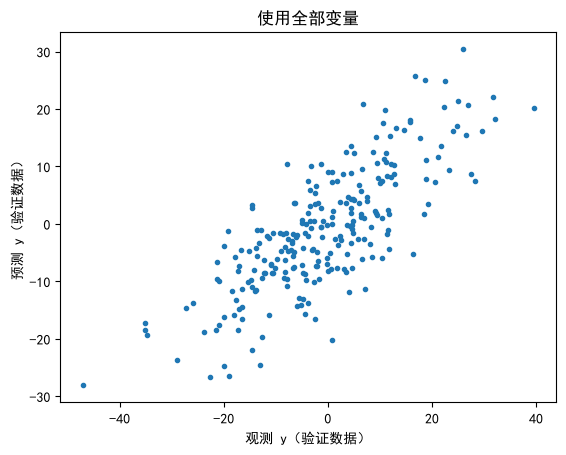

In [8]:
# 在训练数据上拟合模型
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from matplotlib import pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'PingFang SC', 'WenQuanYi Micro Hei']
plt.rcParams['axes.unicode_minus'] = False
# 对 X 进行标准化
scaler_all = StandardScaler()
X_train_scaled = scaler_all.fit_transform(X_train)
X_val_scaled = scaler_all.transform(X_val)

# 拟合
MLR_all = LinearRegression().fit(X_train_scaled, y_train)

# 预测
y_val_pred = MLR_all.predict(X_val_scaled)

# 评分
R2_all_train = MLR_all.score(X_train_scaled, y_train)
R2_all = MLR_all.score(X_val_scaled, y_val)
print(R2_all)

# 绘制真实值与预测值对比图
plt.figure()
plt.plot(y_val, y_val_pred, '.')
plt.title('使用全部变量')
plt.xlabel('观测 y（验证数据）')
plt.ylabel('预测 y（验证数据）')
plt.show()

In [5]:
# %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
##           仅使用 10 个相关变量的 MLR
## %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

0.6339710202313695


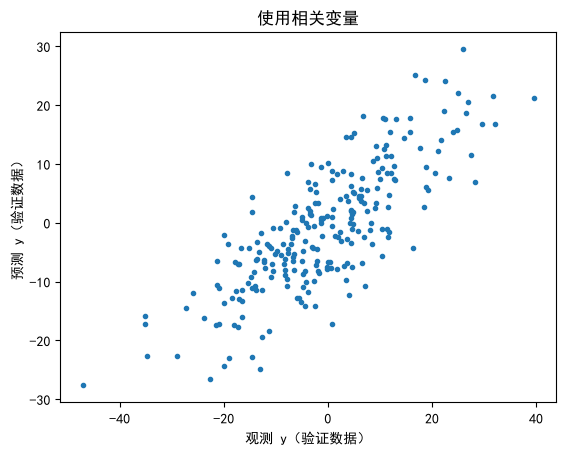

In [9]:
# 仅选取相关输入变量
k = 10
X_train_rel = X_train[:,16:16+k]
X_val_rel = X_val[:,16:16+k]

# 对 X 进行标准化
scaler_rel = StandardScaler()
X_train_rel_scaled = scaler_rel.fit_transform(X_train_rel)
X_val_rel_scaled = scaler_rel.transform(X_val_rel)

# 拟合
MLR_rel = LinearRegression().fit(X_train_rel_scaled, y_train)

# 预测
y_val_rel_pred = MLR_rel.predict(X_val_rel_scaled)

# 评分
R2_rel_train = MLR_rel.score(X_train_rel_scaled, y_train)
R2_rel = MLR_rel.score(X_val_rel_scaled, y_val)
print(R2_rel)

# 绘制真实值与预测值对比图
plt.figure()
plt.plot(y_val, y_val_rel_pred, '.')
plt.title('使用相关变量')
plt.xlabel('观测 y（验证数据）')
plt.ylabel('预测 y（验证数据）')
plt.show()